# Notebook 12: Actor-Critic Methods

**Series:** Reinforcement Learning Basics (12/20)

---

## 1. Motivation

REINFORCE has **high variance** because $G_t$ depends on many random variables. The Actor-Critic framework reduces variance by using a **learned value function** (critic) instead of sample returns.

## 2. Architecture

- **Actor:** Policy $\pi_\theta(a|s)$ — decides what to do
- **Critic:** Value function $\hat{V}_w(s)$ — evaluates how good the state is

## 3. One-Step Actor-Critic

**TD Error (serves as advantage estimate):**
$$\delta_t = R_{t+1} + \gamma \hat{V}_w(S_{t+1}) - \hat{V}_w(S_t)$$

**Actor Update:**
$$\theta \leftarrow \theta + \alpha_\theta \, \delta_t \, \nabla_\theta \log \pi_\theta(A_t|S_t)$$

**Critic Update:**
$$w \leftarrow w + \alpha_w \, \delta_t \, \nabla_w \hat{V}_w(S_t)$$

## 4. A2C (Advantage Actor-Critic)

Uses the advantage $A(s,a) = Q(s,a) - V(s) \approx \delta_t$:

$$\nabla_\theta J(\theta) \approx \sum_t \nabla_\theta \log \pi_\theta(A_t|S_t) \, \hat{A}_t$$

where $\hat{A}_t = \delta_t = R_{t+1} + \gamma V_w(S_{t+1}) - V_w(S_t)$

## 5. Why Actor-Critic Works

- $\delta_t$ is an **unbiased estimate** of the advantage $A^\pi(S_t, A_t)$
- Lower variance than MC returns $G_t$
- Can learn **online** (every step, not just episode end)
- **Two-timescale** convergence: critic learns faster, actor uses critic's estimates

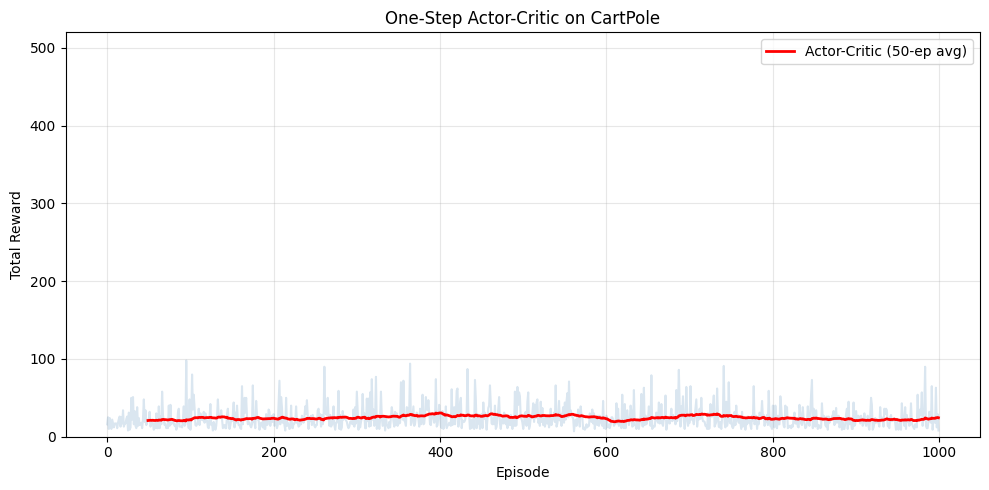

Last 100 episodes avg: 23.3


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Reuse CartPole from Notebook 11
class CartPole:
    def __init__(self):
        self.gravity = 9.8; self.masscart = 1.0; self.masspole = 0.1
        self.total_mass = 1.1; self.length = 0.5
        self.polemass_length = 0.05; self.force_mag = 10.0; self.tau = 0.02
        self.theta_threshold = 12 * np.pi / 180; self.x_threshold = 2.4
    def reset(self):
        self.state = np.random.uniform(-0.05, 0.05, 4); return self.state.copy()
    def step(self, action):
        x, xd, th, thd = self.state; f = self.force_mag if action == 1 else -self.force_mag
        ct, st = np.cos(th), np.sin(th)
        tmp = (f + self.polemass_length * thd**2 * st) / self.total_mass
        thacc = (self.gravity*st - ct*tmp) / (self.length*(4/3 - self.masspole*ct**2/self.total_mass))
        xacc = tmp - self.polemass_length*thacc*ct/self.total_mass
        self.state = np.array([x+self.tau*xd, xd+self.tau*xacc, th+self.tau*thd, thd+self.tau*thacc])
        done = abs(self.state[0]) > self.x_threshold or abs(self.state[2]) > self.theta_threshold
        return self.state.copy(), 1.0 if not done else 0.0, done

# ============================================
# One-Step Actor-Critic
# ============================================
def actor_critic(n_episodes=1000, alpha_theta=0.002, alpha_w=0.01, gamma=0.99):
    env = CartPole()
    theta = np.zeros((4, 2))  # actor weights
    w = np.zeros(4)            # critic weights
    rewards_history = []

    for ep in range(n_episodes):
        state = env.reset()
        total_reward = 0
        for t in range(500):
            # Actor: softmax policy
            logits = state @ theta
            logits -= np.max(logits)
            probs = np.exp(logits) / np.sum(np.exp(logits))
            action = np.random.choice(2, p=probs)

            next_state, reward, done = env.step(action)
            total_reward += reward

            # TD Error
            v_current = state @ w
            v_next = 0 if done else next_state @ w
            delta = reward + gamma * v_next - v_current

            # Critic update
            w += alpha_w * delta * state

            # Actor update
            grad_log = -probs.copy()
            grad_log[action] += 1
            theta += alpha_theta * delta * np.outer(state, grad_log)

            state = next_state
            if done:
                break
        rewards_history.append(total_reward)
    return rewards_history

# Run and compare with REINFORCE
np.random.seed(42)
ac_rewards = actor_critic(1000)

plt.figure(figsize=(10, 5))
window = 50
smoothed = np.convolve(ac_rewards, np.ones(window)/window, mode='valid')
plt.plot(ac_rewards, alpha=0.2, color='steelblue')
plt.plot(range(window-1, len(ac_rewards)), smoothed, 'r-', linewidth=2, label='Actor-Critic (50-ep avg)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.title('One-Step Actor-Critic on CartPole')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 520)
plt.tight_layout()
plt.show()
print(f"Last 100 episodes avg: {np.mean(ac_rewards[-100:]):.1f}")

## Summary

| Component | Update |
|-----------|--------|
| **Critic** | $w \leftarrow w + \alpha_w \delta_t \nabla_w \hat{V}_w(S_t)$ |
| **Actor** | $\theta \leftarrow \theta + \alpha_\theta \delta_t \nabla_\theta \log \pi_\theta(A_t|S_t)$ |
| **TD Error** | $\delta_t = R_{t+1} + \gamma \hat{V}_w(S_{t+1}) - \hat{V}_w(S_t)$ |

**Next:** Notebook 13 — Advantage Functions & GAE